In [5]:
import shapely
from shapely.wkt import loads

In [4]:
!pip install mapclassify folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 30.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 13.3 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [folium]2m5/9 [scikit-learn]


In [2]:
import geopandas as gpd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
from IPython.display import HTML

In [62]:
def show_map(m):
    return HTML(f"<div style='width:800px; height:500px'>{m._repr_html_()}</div>")
    
import folium

def create_gdf(geometries, text_location: list[list[float]]):
    return gpd.GeoDataFrame({
        "geometry": geometries,
        "color": ["red", "green"],
        "marker_size": [15, 3],
        "name": ["B", "A"],
        "text_location": text_location,
    })

def create_map(
    gdf,
    title: str,
    location: tuple[int],
    zoom: int = 5,
    order:list[int] = [0, 1]
):
    m = gdf.explore(
        location=location,
        zoom_start=7,
        color=gdf["color"], 
        marker_kwds={"radius": [10], "weight": 10},
        width=800,
        height=400,
        zoom=zoom,
        style_kwds={"weight": 3}
    )
    
    for _, row in gdf.iterrows():
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        label_text = f"<span style='color:{row['color']};'>{row['name']}</span>"
        
        folium.Marker(
            location=row["text_location"],
            icon=folium.DivIcon(
                html=f"""<div style="font-size:20px; font-weight:bold; background:{{row['color']}};">{label_text}</div>"""
            )
        ).add_to(m)
    
    title_html = f'<h3 align="center" style="font-size:20px"><b>{title}</b></h3>'
    m.get_root().html.add_child(folium.Element(title_html))

    return m

def get_condition_text(field: bool) -> str:
    if field:
        return "TRUE"

    return "FALSE"

# ST_Intersects

## Example 1

In [63]:
polygon_a = Point(0.5, 0.5).buffer(0.3)
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.5, 1.0], [0.5, 0.5]],
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(polygon_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1),
        order=[1, 0]
    )
)

# gdf.to_dict(orider)

## Example 2

In [15]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(2, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.75], [0.57, 2]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(polygon_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 3

In [239]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(1.5, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.75], [0.57, 1.5]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# Example 4

In [189]:
linestring_b = loads("LINESTRING(0 0, 1 0.5, 1.5 1.2, 2.5 1.0, 3.0 0.6)")
linestring_a = loads("LINESTRING(1.2 0.1, 1.1 1.7, 2.1 2.1)")

gdf = create_gdf(
    geometries=[linestring_b, linestring_a],
    text_location=[[-0.0, -0.1], [2.2, 2.3]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(linestring_a.intersects(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.8, 1.2)
    )
)

# Example 5

In [190]:
linestring_b = loads("LINESTRING(0 0, 1 0.5, 1.5 1.2, 2.5 1.0, 3.0 0.6)")
point_a = loads("POINT(1.5 1.2)")

gdf = create_gdf(
    geometries=[linestring_b, point_a],
    text_location=[[-0.0, -0.1], [2.2, 2.3]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(point_a.intersects(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.8, 1.2)
    )
)

## Example 6

In [236]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
linestring_a = loads("LINESTRING(0 -0.5, 0 1.5)")

gdf = create_gdf(
    geometries=[polygon_b, linestring_a],
    text_location=[[0.57, 0.75], [0.5, -0.2]]
)

title = f"ST_Intrsects(A, B) -> {get_condition_text(linestring_a.intersects(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Contains

## Example 1

In [6]:
polygon_b = Point(1.0, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.0], [0.57, 0.50]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 2

In [7]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(1.0, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.50], [0.57, 1.0]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# Example 3

In [8]:
polygon_b = Point(1.5, 0.5)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [0.57, 0.75]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 4

In [9]:
polygon_b = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")
polygon_a = Point(2.0, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.75], [0.57, 2.0]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

## Example 5

In [10]:
polygon_b = Point(1.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.5], [0.57, 0.75]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# Example 6

In [13]:
polygon_b = Point(2.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 2.5], [0.57, 0.75]]
)

title = f"ST_Contains(A, B) -> {get_condition_text(polygon_a.contains(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# 

# ST_Crosses

In [16]:
polygon_b = Point(1.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.5], [0.57, 0.75]]
)

title = f"ST_Crosses(A, B) -> {get_condition_text(polygon_a.crosses(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [64]:
linestring_b = loads("Linestring(0 0, 0.5 0.8, 1.5 1.8)")
linestring_a = loads("Linestring(-1 1, 1 1, 1.4 0.5, 1.6 0.7, 2.0 0.5)")

gdf = create_gdf(
    geometries=[linestring_b, linestring_a],
    text_location=[[0, 0], [1, -1]]
)

title = f"ST_Crosses(A, B) -> {get_condition_text(linestring_a.crosses(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [95]:
linestring_b = loads("Linestring(-1 0.5, 0.1 0.6, 0.75 0.8, 1.1 0.6, 2 -0.2)")
linestring_a = loads("Linestring(-1 1, 1 1, 1.4 0.5, 1.6 0.7, 2.0 0.5)")

gdf = create_gdf(
    geometries=[linestring_b, linestring_a],
    text_location=[[0.4, -1], [0.9, -1]]
)

title = f"ST_Crosses(A, B) -> {get_condition_text(linestring_a.crosses(linestring_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Disjoin

In [99]:
polygon_b = Point(1.5, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.5], [0.57, 0.75]]
)

title = f"ST_Disjoint(A, B) -> {get_condition_text(polygon_a.disjoint(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [102]:
polygon_b = Point(1.9, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Disjoint(A, B) -> {get_condition_text(polygon_a.disjoint(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Equals

In [104]:
polygon_b = Point(1.9, 0.5).buffer(0.3)
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [107]:
polygon_b = Point(1.9, 0.5).buffer(0.3)
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [115]:
polygon_b = Point(0.9, 0.5).buffer(0.3)
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.17, 0.8], [0.57, 0.45]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [117]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = loads("POLYGON((0 0, 0 1, 1.5 1, 1.5 0, 0 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Equals(A, B) -> {get_condition_text(polygon_a.equals(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Overlaps

In [124]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.75]]
)

title = f"ST_Overlaps(A, B) -> {get_condition_text(polygon_a.overlaps(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [135]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(1.4, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 1.4]]
)

title = f"ST_Overlaps(A, B) -> {get_condition_text(polygon_a.overlaps(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Touches

In [149]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = loads("POLYGON((2.5 0, 2.5 1, 4.0 1, 4.0 0, 2.5 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [0.57, 3.2]]
)

title = f"ST_Touches(A, B) -> {get_condition_text(polygon_a.touches(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [159]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = loads("POLYGON((1.5 0.5, 1.5 1.5, 3.0 1.5, 3.0 0.5, 1.5 0.5))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 0.9], [1.10, 3.2]]
)

title = f"ST_Touches(A, B) -> {get_condition_text(polygon_a.touches(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Within

In [165]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(1.4, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 1.4]]
)

title = f"ST_Within(A, B) -> {get_condition_text(polygon_a.within(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [173]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(0.9, 0.5).buffer(0.3)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.9]]
)

title = f"ST_Within(A, B) -> {get_condition_text(polygon_a.within(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Covers

In [182]:
polygon_b = Point(1.9, 0.7).buffer(0.3)
polygon_a = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.9], [0.57, 0.9]]
)

title = f"ST_Within(A, B) -> {get_condition_text(polygon_a.covers(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_Covers

In [ ]:
polygon_b = Point(2.5, 1.0)
polygon_a = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[1.3, 2.5], [0.57, 1.7]]
)

title = f"ST_Covers(A, B) -> {get_condition_text(polygon_a.covers(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [208]:
polygon_b = Point(2.7, 1.0)
polygon_a = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[1.3, 2.7], [0.57, 1.7]]
)

title = f"ST_Covers(A, B) -> {get_condition_text(polygon_a.covers(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

# ST_CoveredBy

In [220]:

polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(2.5, 1.0)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [1.3, 2.5]]
)

title = f"ST_CoveredBy(A, B) -> {get_condition_text(polygon_a.covered_by(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [218]:
polygon_b = loads("POLYGON((1 0, 1 1, 2.5 1, 2.5 0, 1 0))")
polygon_a = Point(2.7, 1.0)

gdf = create_gdf(
    geometries=[polygon_b, polygon_a],
    text_location=[[0.57, 1.7], [1.3, 2.7]]
)

title = f"ST_CoveredBy(A, B) -> {get_condition_text(polygon_a.covered_by(polygon_b))}"

show_map(
    create_map(
        gdf,
        title=title,
        location=(0.5, 1)
    )
)

In [ ]:
# Dem Model

In [6]:
from shapely.geometry.collection import GeometryCollection

In [7]:
poly = loads(
    """
    POLYGON ((-46.947327 -23.654588, -46.9487 -23.469545, -46.711121 -23.397724, -46.487274 -23.410327, -46.344452 -23.48592, -46.290894 -23.644524, -46.360931 -23.722497, -46.647949 -23.771521, -46.878662 -23.735069, -46.947327 -23.654588), (-46.855316 -23.606779, -46.863556 -23.495996, -46.766052 -23.470805, -46.638336 -23.465766, -46.558685 -23.5237, -46.528473 -23.614329, -46.753693 -23.635718, -46.855316 -23.606779))
    """
)

In [8]:
line = loads("""
LINESTRING (-46.988525 -23.344778, -46.771545 -23.569022, -46.149445 -23.732555)
""")

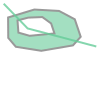

In [9]:
GeometryCollection([poly, line])

In [ ]:
line.relate(poly)

'101FF0212'

In [227]:
poly.relate(line)

'1F20F1102'